# Binary Association

First, some setup of the python environment, for reproducibility:

In [1]:
import numpy as np
import networkx as nx
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
plt.rc('figure', figsize=(3.0, 2.0))
sns.set_theme(style='white')
# imgpath=Path('../../docs/user-guide/img/')

We are going to generate a random bipartite graph, as a stand-in for a binary feature matrix. 
This can represent a document-term matrix, user-preference (recommender) data, or any number of similar feature matrices. 


:::{figure}

In [2]:
n_cols=15
n_rows=30
B = nx.bipartite.random_graph(n_cols,n_rows, .25, seed=2)
n = list(B.nodes)[n_cols:]

X = nx.bipartite.biadjacency_matrix(B, n).toarray()


Each row is an "observation", while each column is a feature that can be active or inactive, _during_ that observation. 


In [3]:
cooc = X.T@X

In [4]:
import affinis.associations as aff
coo = aff.coocur_prob(X)
cos = aff.ochiai(X)
hyp = aff.hyperbolic_project(X)
rsc = aff.resource_project(X)
hss = aff.high_salience_skeleton(X)
dsf = aff.doubly_stochastic_filter(X, reg=0.2)
clt = aff.chow_liu(X)
fps = aff.forest_pursuit(X)

In [5]:
from affinis.plots import hinton

methods = {
    'D.S. Filter': dsf,
    'Forest Pursuit': fps,  
    'HSS': hss,
    'Co-occurrence Prob.': coo,
    'Cosine Sim.': cos,
    'odds-ratio': aff.odds_ratio(X),
    'Yule\'s Y':aff.yule_y(X),
    'Hyperbolic Proj.': hyp,
    'Resource Alloc.':rsc,
}


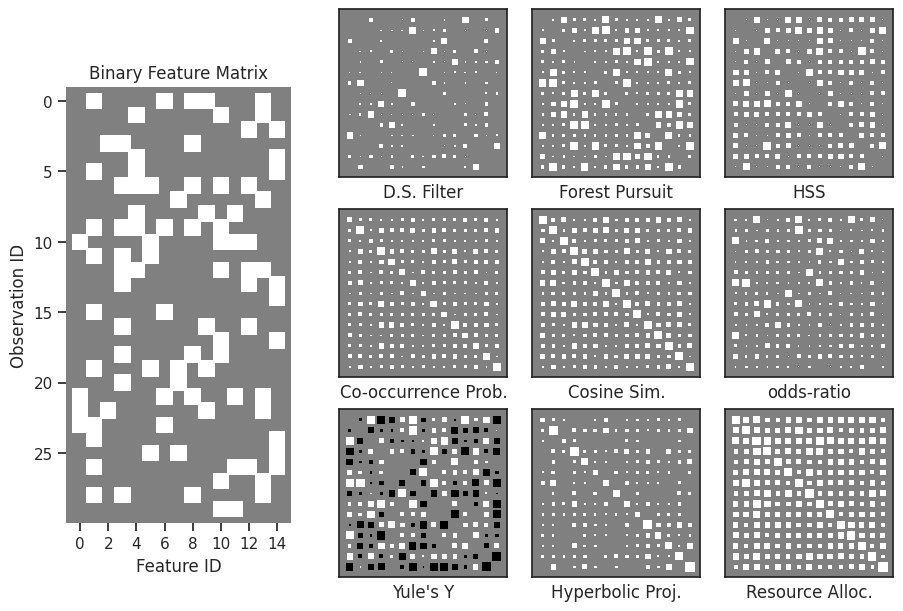

In [19]:
#| label: fig:assoc-meas

fig = plt.figure(layout='constrained', figsize=(9, 6))
subfigs = fig.subfigures(1, 2, wspace=0.07, width_ratios=[1,2])

ax = subfigs[0].subplots(1,1)
hinton(X, ax=ax, marker='s')
# ax.spy(X, marker='s', color='k', markersize=9)

sns.despine(left=True, bottom=True, ax=ax)
ax.xaxis.set_ticks_position('bottom') 
ax.yaxis.set_ticks_position('left') 

ax.set(
    xticks=np.arange(0,n_cols,2)+0.5, xticklabels=range(0,n_cols,2),
    yticks=np.arange(0,n_rows,5)+0.5, yticklabels=range(0,n_rows,5),
    title="Binary Feature Matrix",
    xlabel="Feature ID", ylabel="Observation ID"
);

axs_compare = subfigs[-1].subplots(nrows=3, ncols=3)
for n, (lab, Aest) in enumerate(methods.items()): 
    ax = axs_compare.flatten()[n]
    hinton(Aest, ax=ax)
    ax.set_xlabel(lab)